# Pasar Rau Sales Analysis — Exploratory Data Analysis

## Objective

Explore the cleaned 2021 sales dataset to understand overall sales performance,
monthly trends, product performance, outlet behavior, salesperson performance,
discount activity, and returns.

## Key Business Questions

1. How did overall sales perform throughout 2021?
2. Which products contributed the most to sales?
3. Which outlets contributed the most to sales?
4. How did salesperson performance differ?
5. How significant were returns and reversals?
6. How were discounts distributed across products, outlets, and salespeople?
7. Are there unusual patterns or anomalies worth further investigation?

#### Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/processed/pasar_rau_sales_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["invoice_date"]
)

df.shape

(10678, 34)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10678 entries, 0 to 10677
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   week                  10678 non-null  int64         
 1   month                 10678 non-null  int64         
 2   quarter               10678 non-null  int64         
 3   distributor_id        10678 non-null  int64         
 4   distributor_name      10678 non-null  str           
 5   salesman_code         10678 non-null  int64         
 6   salesman_name         10678 non-null  str           
 7   invoice_number        10678 non-null  str           
 8   invoice_date          10678 non-null  datetime64[us]
 9   outlet_id             10678 non-null  int64         
 10  outlet_name           10678 non-null  str           
 11  Outlet address        10678 non-null  str           
 12  sku_code              10678 non-null  str           
 13  product_name          10678

In [4]:
df.head()

,week,month,quarter,distributor_id,distributor_name,salesman_code,salesman_name,invoice_number,invoice_date,outlet_id,...,notes_1,notes_2,gsv_millions,pjp,net_sales,invoice_id_reliable,is_exact_duplicate,transaction_type,sales_after_discount,discount_rate
0,1,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021000360,2021-01-06,367304001000328956,...,RINSO MOLTO40,SKU TARGET,0.211,Wednesday,221641.20,True,False,sale,201492.00,0.043992
1,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,RINSO240,SKU TARGET,0.046,Wednesday,48390.73,True,False,sale,43991.57,0.051170
2,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,WIPOL SST,SKU TARGET,0.105,Wednesday,108618.91,True,False,sale,98744.47,0.057125
3,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,RINSO ROYAL20ML,SKU TARGET,0.037,Wednesday,36659.50,True,False,sale,33326.41,0.094840
4,2,1,1,93047001,PT. FAJAR PANGAN LESTARI,21,SAEFUL EFENDI,210021001430,2021-01-13,367304001000328956,...,MOLTOBLU280,SKU TARGET,0.011,Wednesday,12505.45,True,False,sale,11368.59,0.007500


---
## 1. Overall Business Performance

In [5]:
total_gsv = df["gsv"].sum()
total_net_sales = df["net_sales"].sum()
total_discount = df["discount"].sum()
total_tax = df["tax"].sum()
total_units = df["total_quantity_pcs"].sum()

print(f"Total GSV: {total_gsv:,.2f}")
print(f"Total Net Sales: {total_net_sales:,.2f}")
print(f"Total Discount: {total_discount:,.2f}")
print(f"Total Tax: {total_tax:,.2f}")
print(f"Total Units: {total_units:,.0f}")

Total GSV: 2,868,711,422.26
Total Net Sales: 2,946,659,755.63
Total Discount: -189,930,231.21
Total Tax: 267,878,116.36
Total Units: 2,991,187


Does this include returns?

Yes, likely.

So total net sales is probably net of returns, because negative transactions are included.

That’s fine, but we should separate sales and returns too.

In [6]:
transaction_summary = (
    df.groupby("transaction_type")
      .agg(
          rows=("transaction_type", "size"),
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum")
      )
      .sort_values("net_sales", ascending=False)
)

print(transaction_summary)

                     rows     net_sales    quantity
transaction_type                                   
sale                 9813  3.053547e+09  3065082.68
adjustment_or_mixed   163  2.153814e+05        3.00
return                702 -1.071031e+08   -73899.00


In [7]:
transaction_type_summary = (
    df.groupby("transaction_type", dropna=False)
      .agg(
          rows=("transaction_type", "size"),
          total_gsv=("gsv", "sum"),
          total_net_sales=("net_sales", "sum"),
          total_discount=("discount", "sum"),
          total_tax=("tax", "sum"),
          total_units=("total_quantity_pcs", "sum"),
      )
      .sort_values("total_net_sales", ascending=False)
)
pd.options.display.float_format = '{:,.2f}'.format
print(transaction_type_summary)


                     rows        total_gsv  total_net_sales  total_discount  \
transaction_type                                                              
sale                 9813 2,970,895,545.18 3,053,547,432.22 -194,943,765.44   
adjustment_or_mixed   163             0.00       215,381.44      195,800.01   
return                702  -102,184,122.92  -107,103,058.03    4,817,734.22   

                         total_tax  total_units  
transaction_type                                 
sale                277,595,174.92 3,065,082.68  
adjustment_or_mixed      19,579.99         3.00  
return               -9,736,638.55   -73,899.00  


**Observation:**
> The dataset contains 9,813 sale line items, 702 return line items, and 163 adjustment/mixed line items. Adjustment/mixed records have a combined GSV of zero but contribute approximately IDR 215,381 in net sales, with only 3 net units recorded.

**Interpretation:**
> Normal sales account for the overwhelming majority of recorded activity. The adjustment/mixed category behaves differently from standard merchandise sales because financial value is recorded despite almost no corresponding unit movement. This suggests that these records may represent accounting or operational adjustments rather than conventional product sales, although their exact purpose cannot be determined from the available data.

**Business implication:**
> Sales, returns, and adjustment/mixed activity should be reported separately so that underlying sales performance is not obscured by non-standard entries. Adjustment records should also be reviewed as a distinct category before being included in operational KPIs.

---
## 2. Monthly Sales Trend

In [8]:
df["month"] = df["invoice_date"].dt.to_period("M")

In [9]:
monthly_sales = (
    df.groupby("month")
      .agg(
          net_sales=("net_sales", "sum"),
          gsv=("gsv", "sum"),
          discount=("discount", "sum"),
          quantity=("total_quantity_pcs", "sum")
      )
      .reset_index()
)

monthly_sales

,month,net_sales,gsv,discount,quantity
0,2021-01,"167,052,019.14","160,885,033.54","-9,019,616.37","203,397.00"
1,2021-02,"157,521,670.04","152,522,678.69","-9,321,187.93","206,531.00"
2,2021-03,"476,493,919.06","451,949,133.71","-18,772,884.39","541,309.00"
3,2021-04,"183,116,761.19","179,007,573.13","-12,537,827.24","222,437.00"
4,2021-05,"146,829,439.78","144,410,289.31","-10,929,001.10","173,057.00"
5,2021-06,"231,166,675.16","224,284,190.57","-14,132,699.91","332,394.04"
6,2021-07,"313,437,803.88","314,025,392.34","-29,081,949.06","191,915.64"
7,2021-08,"225,598,910.58","220,490,321.32","-15,400,446.26","150,560.00"
8,2021-09,"207,547,771.76","203,163,637.42","-14,483,880.39","224,457.00"
9,2021-10,"365,642,975.96","356,212,271.22","-23,809,614.67","358,041.00"


#### Let's Plot the data

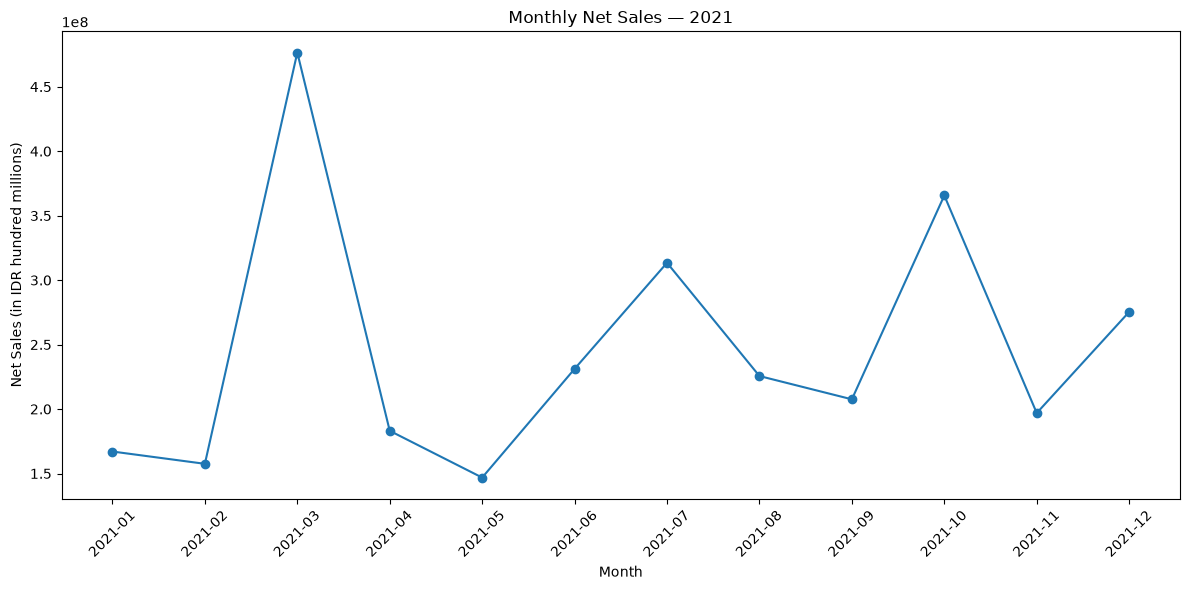

In [39]:
monthly_sales["month"] = monthly_sales["month"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales["month"],
    monthly_sales["net_sales"],
    marker="o"
)
plt.title("Monthly Net Sales — 2021")
plt.xlabel("Month")
plt.ylabel("Net Sales (in IDR hundred millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which months are strongest? March

Which months are weak? May

Are changes gradual or sudden? It's sudden

Do return-heavy months explain dips? We will investigate it.

In [40]:
monthly_returns = (
    df[df["transaction_type"] == "return"]
    .groupby("month")
    .agg(
        return_value=("net_sales", "sum"),
        return_quantity=("total_quantity_pcs", "sum")
    )
    .reset_index()
)

monthly_returns

,month,return_value,return_quantity
0,2021-01,"-3,338,043.23","-4,419.00"
1,2021-02,"-8,466,773.30","-4,899.00"
2,2021-03,"-10,195,103.19","-18,361.00"
3,2021-04,"-6,399,382.40","-4,215.00"
4,2021-05,"-2,213,262.22","-2,407.00"
5,2021-06,"-1,441,605.27",-858.00
6,2021-07,"-264,632.69",-295.00
7,2021-08,"-5,665,774.55","-4,716.00"
8,2021-09,"-5,352,007.83","-4,175.00"
9,2021-10,"-6,685,693.90","-3,599.00"


Did sales fall because fewer products were sold, or because returns increased?

It's a combination of both conditions. For example, in March, Net Sales went up even though the return value were higher than usual, this shows that the return doesn't affect much on the net sales on March, but in November the return value was the highest, which drives the net sales lower than the other months.

In [41]:
monthly_by_type = (
    df.groupby(["month", "transaction_type"])
      .agg(net_sales=("net_sales", "sum"))
      .reset_index()
)

monthly_by_type_pivot = monthly_by_type.pivot(
    index="month",
    columns="transaction_type",
    values="net_sales" 
)
monthly_by_type_pivot

transaction_type,adjustment_or_mixed,return,sale
month,,,
2021-01,"7,607.31","-3,338,043.23","170,382,455.06"
2021-02,"1,433.54","-8,466,773.30","165,987,009.80"
2021-03,"127,897.94","-10,195,103.19","486,561,124.31"
2021-04,425.26,"-6,399,382.40","189,515,718.33"
2021-05,0.00,"-2,213,262.22","149,042,702.00"
2021-06,"8,309.93","-1,441,605.27","232,599,970.50"
2021-07,"7,470.15","-264,632.69","313,694,966.42"
2021-08,"3,838.03","-5,665,774.55","231,260,847.10"
2021-09,"26,312.68","-5,352,007.83","212,873,466.91"


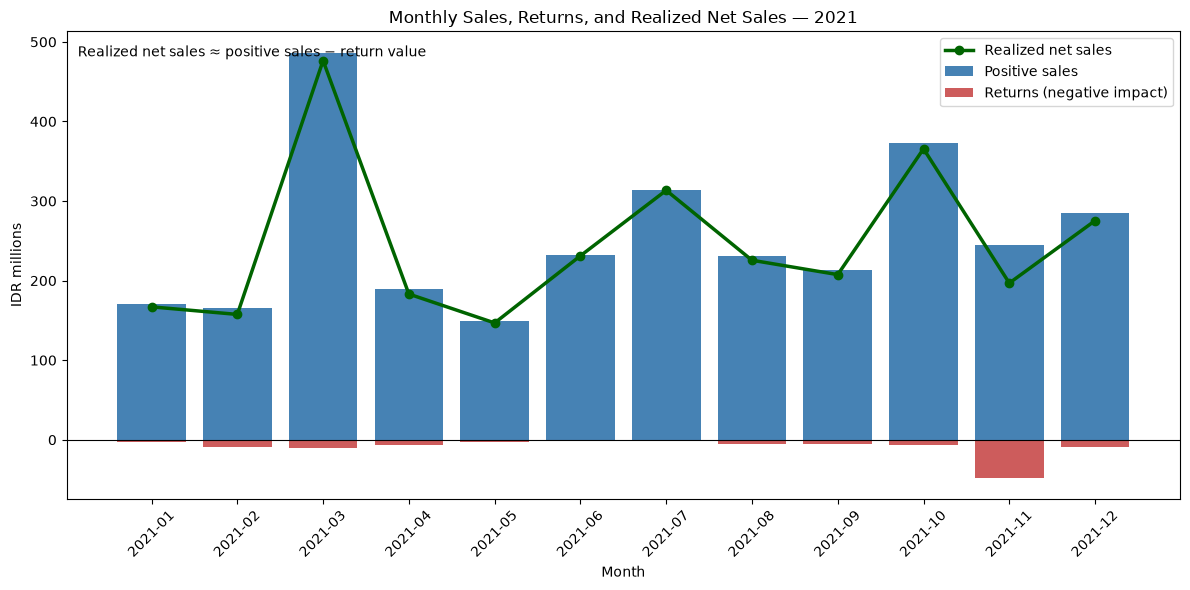

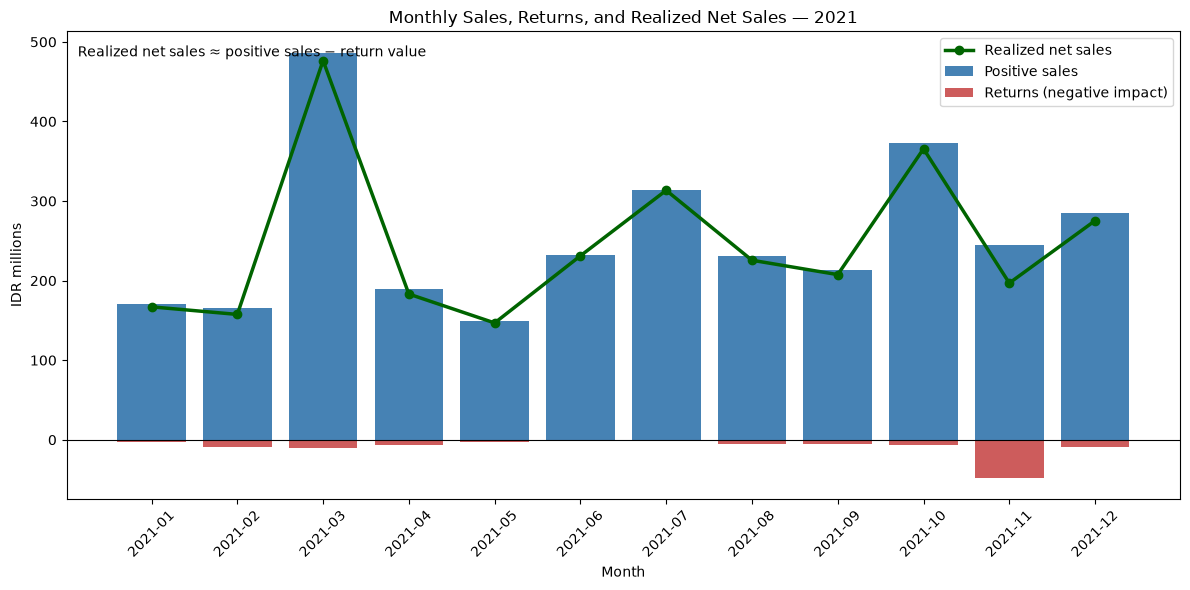

In [42]:
plot_data = monthly_by_type_pivot.sort_index()
months = plot_data.index.astype(str)

sales_millions = plot_data["sale"] / 1_000_000
return_impact_millions = plot_data["return"] / 1_000_000
realized_millions = (
    monthly_sales.set_index("month")
    .reindex(months)["net_sales"]
    / 1_000_000
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(months, sales_millions, label="Positive sales", color="steelblue")
ax.bar(months, return_impact_millions, label="Returns (negative impact)", color="indianred")
ax.plot(
    months,
    realized_millions,
    marker="o",
    linewidth=2.5,
    color="darkgreen",
    label="Realized net sales",
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Monthly Sales, Returns, and Realized Net Sales — 2021")
ax.set_xlabel("Month")
ax.set_ylabel("IDR millions")
ax.text(
    0.01,
    0.97,
    "Realized net sales ≈ positive sales − return value",
    transform=ax.transAxes,
    va="top",
)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plot_data = monthly_by_type_pivot.sort_index()
months = plot_data.index.astype(str)

sales_millions = plot_data["sale"] / 1_000_000
return_impact_millions = plot_data["return"] / 1_000_000  # Returns are already negative
realized_millions = (
    monthly_sales.set_index("month")
    .reindex(months)["net_sales"]
    / 1_000_000
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(months, sales_millions, label="Positive sales", color="steelblue")
ax.bar(months, return_impact_millions, label="Returns (negative impact)", color="indianred")
ax.plot(
    months,
    realized_millions,
    marker="o",
    linewidth=2.5,
    color="darkgreen",
    label="Realized net sales",
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Monthly Sales, Returns, and Realized Net Sales — 2021")
ax.set_xlabel("Month")
ax.set_ylabel("IDR millions")
ax.text(
    0.01,
    0.97,
    "Realized net sales ≈ positive sales − return value",
    transform=ax.transAxes,
    va="top",
)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart highlights that overall sales were highly volatile across the year rather than stable. The strongest sales month was March, when positive sales reached a very high level and the realized net sales line also peaked. This suggests a period of strong demand or favorable commercial conditions.

The most important negative signal appears in November, where returns surged sharply and produced the largest negative impact on net sales. Despite still relatively healthy positive sales in that month, the very large return value drove realized net sales down significantly. This shows that weaker net sales in some months do not always mean weak selling activity alone; they can also reflect elevated product reversals.

Other months such as May and February show weaker realized net sales, but the pattern is not simply “low sales.” In some cases, lower net sales were driven by a combination of lower gross sales and higher returns. This makes it clear that return behavior is a critical factor in interpreting monthly performance.

**Observation:** 
> Monthly net sales varied substantially throughout 2021, with March recording the strongest performance and May one of the weakest periods. The movement is uneven rather than following a consistent upward or downward trend.

**Interpretation:**
> The volatility indicates that sales performance changed materially from month to month. Possible drivers include changes in sales volume, product mix, outlet activity, or return activity; however, the dataset does not contain enough information to directly attribute the pattern to seasonality, promotions, or inventory availability.

**Business implication:**
> Management should investigate the strongest and weakest months by decomposing net sales into sales volume, product mix, outlet contribution, and returns. Monthly performance should also be monitored alongside return activity rather than using net sales alone.

--- 
## 3. Product Performance

In [12]:
product_performance = (
    df.groupby(["sku_code", "product_name"])
      .agg(
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum"),
          gsv=("gsv", "sum"),
          discount=("discount", "sum")
      )
      .sort_values("net_sales", ascending=False)
)

product_performance.head(20)

,,net_sales,quantity,gsv,discount
sku_code,product_name,,,,
68211855,BANGO MANIS RL 144X20ML,"413,818,844.65","556,752.00","404,909,491.00","-28,710,543.44"
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"239,491,078.16","157,695.04","238,532,619.75","-20,813,459.54"
62072024,PEPSODENT WHITE 75GR/144,"194,365,683.59","54,367.00","196,537,290.87","-19,841,223.93"
68499084,PEPSODENT STRONG 12 PROMO 72X(75+25)G,"179,136,863.59","60,576.00","165,207,578.68","-2,355,885.70"
68144289,RINSO MOLTO ROSE FRESH PWD 126X44G,"144,475,389.14","194,851.00","142,595,363.94","-11,254,107.77"
68410975,ROYCO FDS CHICKEN RL 576X8G,"105,016,980.70","292,416.00","99,687,457.34","-4,217,487.41"
68571429,BANGO MANIS PROMO 48X(60+6ML),"100,354,015.78","41,955.64","97,293,564.79","-6,062,641.52"
68493636,FAIR & LOVELY G&L MVIT CREAM 12X12X9G,"93,112,474.02","32,377.00","97,106,999.84","-12,459,296.69"
68576741,PEPSODENT STRONG 12 JAM 72X(75G+15G),"85,052,308.57","29,754.00","78,183,252.99","-862,978.74"


Which products generate the most net sales?

Top 3: 
1. BANGO MANIS RL 144X20ML
2. SUNLIGHT LIME NEW POUCH 72X105ML
3. PEPSODENT WHITE 75GR/144

In [13]:
product_performance.sort_values(
    "quantity",
    ascending=False
).head(20)

,,net_sales,quantity,gsv,discount
sku_code,product_name,,,,
68211855,BANGO MANIS RL 144X20ML,"413,818,844.65","556,752.00","404,909,491.00","-28,710,543.44"
68410975,ROYCO FDS CHICKEN RL 576X8G,"105,016,980.70","292,416.00","99,687,457.34","-4,217,487.41"
68144289,RINSO MOLTO ROSE FRESH PWD 126X44G,"144,475,389.14","194,851.00","142,595,363.94","-11,254,107.77"
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"239,491,078.16","157,695.04","238,532,619.75","-20,813,459.54"
67762152,RINSO MOLTO ROSE FRESH LIQ 144X40ML,"76,724,077.11","103,446.00","75,708,921.21","-5,959,763.50"
68410982,ROYCO FDS BEEF RL 576X9G,"34,821,299.90","96,852.00","33,017,788.55","-1,362,080.88"
68688884,RINSO MOLTO ROSE FRESH PWD 126X42G,"66,703,630.44","88,068.00","64,465,362.04","-3,825,700.73"
68143147,SARIWANGI ASLI RL TB 288X(4X1.85G),"64,653,419.29","86,880.00","63,185,591.79","-4,409,758.85"
68498853,LIFEBUOY SHP KUAT&BKLAU 12+1(480+40)X9ML,"28,870,842.11","83,868.00","28,591,300.10","-2,345,081.16"


Highest-volume products: 
1. BANGO MANIS RL 144X20ML
2. ROYCO FDS CHICKEN RL 576X8G
3. RINSO MOLTO ROSE FRESH PWD 126X44G

#### Products with the biggest returned value: 

In [14]:
product_returns = (
    df[df["transaction_type"] == "return"]
    .groupby(["sku_code", "product_name"])
    .agg(
        return_value=("net_sales", "sum"),
        return_quantity=("total_quantity_pcs", "sum")
    )
)

product_returns.sort_values("return_value").head(20)

,,return_value,return_quantity
sku_code,product_name,,
68576741,PEPSODENT STRONG 12 JAM 72X(75G+15G),"-40,607,202.62","-15,936.00"
68493419,FAIR & LOVELY G&L MVIT FC FOAM 12X12X9G,"-9,417,356.47","-4,296.00"
68571429,BANGO MANIS PROMO 48X(60+6ML),"-5,746,825.36","-2,551.00"
67907162,LIFEBUOY SHP PRAWTN RMBT RNTK 480X1X9ML,"-5,412,939.51","-14,940.00"
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"-2,028,177.93","-1,440.00"
67594358,WIPOL KARBOL CEMARA REFILL 12X780ML,"-1,997,798.90",-114.00
68706458,VIXAL PEMB PORS BIRU BTL 24X175ML,"-1,737,583.61",-420.00
68211855,BANGO MANIS RL 144X20ML,"-1,470,300.05","-1,968.00"
67719159,SUNLIGHT LIME NEW POUCH 24X210ML,"-1,062,449.97",-253.00


In [43]:
product_ranked = (
    product_performance
    .sort_values("net_sales", ascending=False)
    .copy()
)

product_ranked["sales_share"] = (
    product_ranked["net_sales"]
    / product_ranked["net_sales"].sum()
)

product_ranked["cumulative_share"] = (
    product_ranked["sales_share"].cumsum()
)

product_ranked.head(20)

,,net_sales,quantity,gsv,discount,sales_share,cumulative_share
sku_code,product_name,,,,,,
68211855,BANGO MANIS RL 144X20ML,"413,818,844.65","556,752.00","404,909,491.00","-28,710,543.44",0.14,0.14
68386572,SUNLIGHT LIME NEW POUCH 72X105ML,"239,491,078.16","157,695.04","238,532,619.75","-20,813,459.54",0.08,0.22
62072024,PEPSODENT WHITE 75GR/144,"194,365,683.59","54,367.00","196,537,290.87","-19,841,223.93",0.07,0.29
68499084,PEPSODENT STRONG 12 PROMO 72X(75+25)G,"179,136,863.59","60,576.00","165,207,578.68","-2,355,885.70",0.06,0.35
68144289,RINSO MOLTO ROSE FRESH PWD 126X44G,"144,475,389.14","194,851.00","142,595,363.94","-11,254,107.77",0.05,0.40
68410975,ROYCO FDS CHICKEN RL 576X8G,"105,016,980.70","292,416.00","99,687,457.34","-4,217,487.41",0.04,0.43
68571429,BANGO MANIS PROMO 48X(60+6ML),"100,354,015.78","41,955.64","97,293,564.79","-6,062,641.52",0.03,0.47
68493636,FAIR & LOVELY G&L MVIT CREAM 12X12X9G,"93,112,474.02","32,377.00","97,106,999.84","-12,459,296.69",0.03,0.50
68576741,PEPSODENT STRONG 12 JAM 72X(75G+15G),"85,052,308.57","29,754.00","78,183,252.99","-862,978.74",0.03,0.53


The top 10 products represent roughly 55% of net sales.

**Observation:**

> Revenue is highly concentrated among a small number of SKUs. The top-selling product contributes approximately 14% of net sales, while the top 10 products—less than 2% of the product assortment—generate roughly 55% of total net sales. 
> - The top 3 products that generated the most net sales are: 
>> 1. BANGO MANIS RL 144X20ML
>> 2. SUNLIGHT LIME NEW POUCH 72X105ML
>> 3. PEPSODENT WHITE 75GR/144
> - The top 3 products with highest volume are:
>> 1. BANGO MANIS RL 144X20ML
>> 2. ROYCO FDS CHICKEN RL 576X8G
>> 3. RINSO MOLTO ROSE FRESH PWD 126X44G
> - The top 3 products with highest returns are: 
>> 1. PEPSODENT STRONG 12 JAM 72X(75G+15G)
>> 2. FAIR & LOVELY G&L MVIT FC FOAM 12X12X9G
>> 3. BANGO MANIS PROMO 48X(60+6ML)

**Interpretation:** 
> Product performance is concentrated, so revenue appears to be highly dependent on a few high-volume items rather than the broader assortment.

**Business implication:** 
> High-performing SKUs should receive particular attention in availability and sales planning because disruption to a small number of major products could materially affect revenue. Products with high return values should be investigated separately to determine whether return activity is concentrated around particular SKUs.


--- 
## 4. Outlet Performance

In [15]:
total_outlets = df["outlet_id"].nunique()
print(f"Total number of outlets: {total_outlets:,}")

Total number of outlets: 53


In [16]:
outlet_performance = (
    df.groupby(["outlet_id", "outlet_name"])
      .agg(
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum"),
          sku_count=("sku_code", "nunique"),
          active_days=("invoice_date", "nunique")
      )
      .sort_values("net_sales", ascending=False)
)

outlet_performance.head(20)

,,net_sales,quantity,sku_count,active_days
outlet_id,outlet_name,,,,
367304000300329558,ALIONG (NIK),"1,484,850,765.97","1,587,112.68",119,94
367304000400327721,YANTI (NIK),"391,509,436.10","494,661.00",63,68
367304000400329545,"ASEP,TK (NIK)","149,636,536.41","47,821.00",52,13
367301000600329508,"BAHRUDIN,H (NIK)","117,529,476.89","81,005.00",104,37
367304000400327430,ALAMI (NIK),"110,265,003.57","54,348.00",271,21
367304000400327448,YUDI (NIK),"67,333,971.16","92,050.00",174,59
367304000400327787,ITA.TK (NIK),"50,319,862.45","18,579.00",137,20
367304000300329558,ALIONG,"48,008,764.23","68,856.00",12,5
367304001000328956,"AAS, IBU (NIK)","43,155,317.48","61,842.00",122,55


Are sales concentrated among a few outlets?

One outlet outperformed the others which is 
`ALIONG (NIK)` which contributed 1,484,850,765.97 of net sales.

In [17]:
outlet_performance["sales_share"] = (
    outlet_performance["net_sales"]
    / outlet_performance["net_sales"].sum()
)

outlet_performance.head(20)

,,net_sales,quantity,sku_count,active_days,sales_share
outlet_id,outlet_name,,,,,
367304000300329558,ALIONG (NIK),"1,484,850,765.97","1,587,112.68",119,94,0.50
367304000400327721,YANTI (NIK),"391,509,436.10","494,661.00",63,68,0.13
367304000400329545,"ASEP,TK (NIK)","149,636,536.41","47,821.00",52,13,0.05
367301000600329508,"BAHRUDIN,H (NIK)","117,529,476.89","81,005.00",104,37,0.04
367304000400327430,ALAMI (NIK),"110,265,003.57","54,348.00",271,21,0.04
367304000400327448,YUDI (NIK),"67,333,971.16","92,050.00",174,59,0.02
367304000400327787,ITA.TK (NIK),"50,319,862.45","18,579.00",137,20,0.02
367304000300329558,ALIONG,"48,008,764.23","68,856.00",12,5,0.02
367304001000328956,"AAS, IBU (NIK)","43,155,317.48","61,842.00",122,55,0.01


50% of sales was from outlet_id 367304000300329558 by the name of ALIONG (NIK)

In [44]:
top_outlet = outlet_performance.iloc[0]

top_outlet_share = (
    top_outlet["net_sales"]
    / outlet_performance["net_sales"].sum()
)

top_outlet_share

np.float64(0.5039098128424864)

In [45]:
top5_share = (
    outlet_performance
    .sort_values("net_sales", ascending=False)
    .head(5)["net_sales"]
    .sum()
    / outlet_performance["net_sales"].sum()
)

top5_share

np.float64(0.7648630672862116)

In [18]:
outlet_ranked = (
    outlet_performance
    .sort_values("net_sales", ascending=False)
    .copy()
)

outlet_ranked["cumulative_share"] = (
    outlet_ranked["sales_share"].cumsum()
)

outlet_ranked.head(20)

,,net_sales,quantity,sku_count,active_days,sales_share,cumulative_share
outlet_id,outlet_name,,,,,,
367304000300329558,ALIONG (NIK),"1,484,850,765.97","1,587,112.68",119,94,0.50,0.50
367304000400327721,YANTI (NIK),"391,509,436.10","494,661.00",63,68,0.13,0.64
367304000400329545,"ASEP,TK (NIK)","149,636,536.41","47,821.00",52,13,0.05,0.69
367301000600329508,"BAHRUDIN,H (NIK)","117,529,476.89","81,005.00",104,37,0.04,0.73
367304000400327430,ALAMI (NIK),"110,265,003.57","54,348.00",271,21,0.04,0.76
367304000400327448,YUDI (NIK),"67,333,971.16","92,050.00",174,59,0.02,0.79
367304000400327787,ITA.TK (NIK),"50,319,862.45","18,579.00",137,20,0.02,0.80
367304000300329558,ALIONG,"48,008,764.23","68,856.00",12,5,0.02,0.82
367304001000328956,"AAS, IBU (NIK)","43,155,317.48","61,842.00",122,55,0.01,0.84


Top 5 outlets contribute 75%+ of sales

**Observation:**
> - The total number of outlets is 53
> - One outlet `ALIONG (NIK)`, outperformed the others which contributed 1,484,850,765.97 net sales. That is roughly 50% of  all outlets' combined total net sales during that year.
> - Top 5 outlets contribute more than 75% of sales: 
>> 1. ALIONG (NIK)
>> 2. YANTI (NIK)
>> 3. ASEP,TK (NIK)
>> 4. BAHRUDIN,H (NIK)
>> 5. ALAMI (NIK)

**Interpretation:** 
> Sales are extremely concentrated among a small number of outlets, particularly ALIONG. The dataset does not show whether this results from outlet size, purchase frequency, customer type, or other commercial factors.

**Business Implication:** 
> Management might need to maintain a close attention to these key outlets because losing or reducing activity from one of these outlets could affect overall revenue. Management may want to diversify sales across additional outlets.

--- 
## 5. Salesperson Performance

In [19]:
salesman_performance = (
    df.groupby("salesman_name")
      .agg(
          net_sales=("net_sales", "sum"),
          quantity=("total_quantity_pcs", "sum"),
          outlets=("outlet_name", "nunique"),
          products=("sku_code", "nunique"),
          active_days=("invoice_date", "nunique")
      )
      .sort_values("net_sales", ascending=False)
)

salesman_performance

,net_sales,quantity,outlets,products,active_days
salesman_name,,,,,
ZUL RUSMANSYAH,"1,333,515,738.72","1,466,930.68",25,244,142
SAEFUL EFENDI,"476,921,319.70","616,751.00",38,248,84
ADANG,"385,673,207.77","142,377.00",15,384,40
DETI HANDAYANI,"369,545,781.44","342,537.00",10,186,33
SUKMADEWI,"361,780,118.38","398,884.00",15,220,74
ERTM FAJAR SWAT,"11,485,380.73","10,887.00",9,119,45
OB TELEORDER,"7,738,208.89","12,820.00",7,55,23


In [20]:
salesman_performance["sales_per_outlet"] = (
    salesman_performance["net_sales"]
    / salesman_performance["outlets"]
)

salesman_performance["sales_per_product"] = (
    salesman_performance["net_sales"]
    / salesman_performance["products"]
)
salesman_performance["sales_per_day"] = (
    salesman_performance["net_sales"]
    / salesman_performance["active_days"]
)

# Sort by sales per outlet descending
salesman_performance = salesman_performance.sort_values(
    "sales_per_outlet", ascending=False
)

salesman_performance.head(20)

,net_sales,quantity,outlets,products,active_days,sales_per_outlet,sales_per_product,sales_per_day
salesman_name,,,,,,,,
ZUL RUSMANSYAH,"1,333,515,738.72","1,466,930.68",25,244,142,"53,340,629.55","5,465,228.44","9,390,955.91"
DETI HANDAYANI,"369,545,781.44","342,537.00",10,186,33,"36,954,578.14","1,986,805.28","11,198,357.01"
ADANG,"385,673,207.77","142,377.00",15,384,40,"25,711,547.18","1,004,357.31","9,641,830.19"
SUKMADEWI,"361,780,118.38","398,884.00",15,220,74,"24,118,674.56","1,644,455.08","4,888,920.52"
SAEFUL EFENDI,"476,921,319.70","616,751.00",38,248,84,"12,550,561.04","1,923,069.84","5,677,634.76"
ERTM FAJAR SWAT,"11,485,380.73","10,887.00",9,119,45,"1,276,153.41","96,515.80","255,230.68"
OB TELEORDER,"7,738,208.89","12,820.00",7,55,23,"1,105,458.41","140,694.71","336,443.86"


In [46]:
# Net sales of each salesperson by outlet
salesman_outlet = (
    df.groupby(["salesman_name", "outlet_name"])
      .agg(net_sales=("net_sales", "sum"))
      .reset_index()
)

salesman_outlet.sort_values(
    "net_sales",
    ascending=False
).head(20)

,salesman_name,outlet_name,net_sales
97,ZUL RUSMANSYAH,ALIONG (NIK),"1,020,686,280.85"
16,DETI HANDAYANI,ALIONG (NIK),"306,067,520.07"
93,SUKMADEWI,YANTI (NIK),"264,997,729.35"
44,SAEFUL EFENDI,ALIONG (NIK),"158,096,965.05"
2,ADANG,"ASEP,TK (NIK)","149,636,536.41"
77,SAEFUL EFENDI,YANTI (NIK),"126,511,706.75"
1,ADANG,ALAMI (NIK),"110,265,003.57"
99,ZUL RUSMANSYAH,"BAHRUDIN,H (NIK)","84,333,538.60"
10,ADANG,ITA.TK (NIK),"50,319,862.45"
96,ZUL RUSMANSYAH,ALIONG,"48,008,764.23"


In [47]:
# How much of each salesperson's total sales comes from their single largest outlet?

salesman_total = (
    df.groupby("salesman_name")["net_sales"]
      .sum()
)

salesman_top_outlet = (
    salesman_outlet
    .groupby("salesman_name")["net_sales"]
    .max()
)

salesman_concentration = (
    salesman_top_outlet / salesman_total
)

salesman_concentration.sort_values(ascending=False)

salesman_name
DETI HANDAYANI    0.83
ZUL RUSMANSYAH    0.77
SUKMADEWI         0.73
OB TELEORDER      0.40
ADANG             0.39
SAEFUL EFENDI     0.33
ERTM FAJAR SWAT   0.22
Name: net_sales, dtype: float64

**Observation:**
> - ZUL RUSMANSYAH leads with IDR 1.33B in net sales and the strongest sales per outlet, product, and day.
> - Sales performance is highly concentrated among a few salespeople, with large gaps in productivity across the team.

**Interpretation:**
> Salesperson revenue is highly dependent on account allocation. For several representatives, more than 70% of net sales comes from a single outlet, making raw revenue rankings an unreliable measure of individual selling performance.

**Business Implication:**
> Salesperson evaluation should consider account concentration, outlet mix, active days, and sales per outlet alongside total revenue. Raw sales rankings alone may overstate or understate individual performance

### 1) Why does ALIONG contribute ~50%?
Because the outlet concentration is extremely high.

- ALIONG net sales: 1,484,850,765.97
- Total net sales: 2,946,659,755.63
- Share: 1,484,850,765.97 / 2,946,659,755.63 = 50.39%

So ALIONG alone is responsible for roughly half of all net sales in the dataset.

It is not just a large outlet in a general sense; it is overwhelmingly dominant:
- quantity: 1,587,112.68 units
- active days: 94
- 119 SKUs
- next outlet (YANTI) is only 391.5M, which is about 13.3% of total

This means ALIONG is a structural driver of the business and a major source of sales concentration.

### 2) How does outlet concentration affect salesperson rankings?
It distorts the ranking heavily because several reps are effectively tied to a single massive outlet.

Examples:
- ZUL RUSMANSYAH:
    - total net sales = 1,333,515,738.72
    - top outlet = 1,020,686,280.85
    - share of total = 76.6%
- DETI HANDAYANI:
    - total = 369,545,781.44
    - top outlet = 306,067,520.07
    - share = 82.8%
- SUKMADEWI:
    - total = 361,780,118.38
    - top outlet = 264,997,729.35
    - share = 73.3%

This means salesperson rankings are not just “performance across many outlets”; they are often “one giant account drives most of the rep’s result.” In other words, the leaderboard is highly sensitive to outlet mix and account concentration.

### 3) How concentrated is product revenue really?
Very concentrated.

- BANGO MANIS RL 144X20ML = 413,818,844.65
    - share = 14.0% of total net sales
- Top 3 products together = ~847,775,606.40
    - share ≈ 28.8%
- Top 5 products roughly ~1.18B
    - share ≈ 40%
- Top 10 products are about 55% of total revenue

So this is a classic “few SKUs drive most revenue” pattern. The business is not spread evenly across the product portfolio; a small set of core items is carrying the majority of sales.

### 4) How much do returns actually explain the weaker months?
Returns matter a lot in some months, but not in all weak months.

The clearest example is November:
- positive sales = 244,407,294.36
- returns = -47,525,584.50
- realized net sales = 196,892,087.40

So in November:
- the return impact was about 19.5% of positive sales
- it explains almost the entire gap between gross sales and realized net sales

This is the strongest evidence that returns drove a weak month.

But not every weak month is explained by returns:
- May:
    - positive sales = 149,042,702.00
    - returns = -2,213,262.22
    - realized net sales = 146,829,439.78
    - returns are only ~1.5% of sales, so May was weak mainly because sales volume itself was lower
- March:
    - positive sales = 486,561,124.31
    - returns = -10,195,103.19
    - realized net sales = 476,493,919.06
    - even with larger returns, sales were so strong that the month still performed extremely well

Bottom line:
- Returns are not always the main cause of weak months.
- They are a major explanatory factor in extreme return spikes, especially November.
- In most other months, weaker performance is more about lower positive sales than returns alone.

In short: outlet concentration is extreme, product revenue is highly concentrated, and return spikes are a major amplifier of volatility—especially in November.

--- 
## 6. Discount Analysis

In [21]:
df["discount_rate"].describe()

count   10,515.00
mean         0.02
std          0.03
min          0.00
25%          0.00
50%          0.01
75%          0.04
max          0.67
Name: discount_rate, dtype: float64

In [22]:
discount_by_product = (
    df.groupby(["sku_code", "product_name"])
      .agg(
          total_gsv=("gsv", "sum"),
          total_discount=("discount", "sum"),
          net_sales=("net_sales", "sum")
      )
)

discount_by_product["effective_discount_rate"] = (
    discount_by_product["total_discount"].abs()
    / discount_by_product["total_gsv"].abs()
)

discount_by_product.sort_values(
    "effective_discount_rate",
    ascending=False
).head(20)

,,total_gsv,total_discount,net_sales,effective_discount_rate
sku_code,product_name,,,,
68493636,FAIR & LOVELY G&L MVIT CREAM 12X12X9G,"97,106,999.84","-12,459,296.69","93,112,474.02",0.13
68493419,FAIR & LOVELY G&L MVIT FC FOAM 12X12X9G,"42,621,398.48","-5,452,237.93","40,886,077.28",0.13
68374314,FAIR & LOVELY MVT CREAM UV 6X6X15G,"122,400.00","-14,292.65","118,918.90",0.12
21148096,LIFEBUOY BW LEMONFRESH BTL 24X300ML,"65,550.00","-7,410.43","63,953.53",0.11
68382324,BUAVITA GUAVA WD 24X250ML,"1,248,840.00","-138,354.95","1,221,533.55",0.11
68732964,REXONA FREE SPIRIT DEOLOT 144X9G,"18,349,078.16","-2,019,791.98","17,962,214.79",0.11
68211858,BANGO MANIS RL 12X550ML,"80,151,804.50","-8,690,212.75","78,607,751.27",0.11
68493411,FAIR & LOVELY G&L MVIT FC FOAM 24X50G,"2,150,400.00","-227,208.57","2,115,510.58",0.11
68382322,BUAVITA MANGO WD 24X250ML,"746,620.00","-76,221.82","737,438.00",0.10


In [23]:
# discount by outlet

discount_by_outlet = (
    df.groupby(["outlet_id", "outlet_name"])
      .agg(
          total_gsv=("gsv", "sum"),
          total_discount=("discount", "sum"),
          net_sales=("net_sales", "sum")
      )
)

discount_by_outlet["effective_discount_rate"] = (
    discount_by_outlet["total_discount"].abs()
    / discount_by_outlet["total_gsv"].abs()
)

discount_by_outlet.sort_values(
    "effective_discount_rate",
    ascending=False
).head(20)

,,total_gsv,total_discount,net_sales,effective_discount_rate
outlet_id,outlet_name,,,,
367304000400329545,"ASEP,TK (NIK)","150,567,580.68","-14,534,366.03","149,636,536.41",0.10
367304000400328111,AMOR,"589,781.73","-55,945.45","587,222.26",0.09
367304000400327721,YANTI,"10,642,883.00","-926,015.34","10,688,554.43",0.09
367304000400327553,"SUBHAN,TK","534,371.00","-42,751.77","540,782.69",0.08
367304000300329558,ALIONG (NIK),"1,461,888,316.39","-112,023,992.18","1,484,850,765.97",0.08
367304000400327721,YANTI (NIK),"384,406,427.03","-28,488,760.07","391,509,436.10",0.07
367304000300329558,ALIONG,"46,960,043.00","-3,315,711.87","48,008,764.23",0.07
367301000600329508,"BAHRUDIN,H","14,236,557.00","-925,454.64","14,642,212.89",0.07
367304000400328588,"ANI BERSAUDARA,HJ (NIK)","1,006,365.50","-60,000.00","1,041,002.40",0.06


In [24]:
# Discount by salesperson

discount_by_salesman = (
    df.groupby("salesman_name")
      .agg(
          total_gsv=("gsv", "sum"),
          total_discount=("discount", "sum"),
          net_sales=("net_sales", "sum")
      )
)

discount_by_salesman["effective_discount_rate"] = (
    discount_by_salesman["total_discount"].abs()
    / discount_by_salesman["total_gsv"].abs()
)

discount_by_salesman.sort_values(
    "effective_discount_rate",
    ascending=False
).head(20)


,total_gsv,total_discount,net_sales,effective_discount_rate
salesman_name,,,,
DETI HANDAYANI,"362,829,901.43","-26,879,222.01","369,545,781.44",0.07
ZUL RUSMANSYAH,"1,300,171,703.86","-87,884,754.74","1,333,515,738.72",0.07
SUKMADEWI,"352,045,483.54","-23,154,587.15","361,780,118.38",0.07
ADANG,"374,226,304.21","-23,614,337.03","385,673,207.77",0.06
SAEFUL EFENDI,"461,222,375.38","-27,657,642.54","476,921,319.70",0.06
ERTM FAJAR SWAT,"10,922,548.35","-481,308.57","11,485,380.73",0.04
OB TELEORDER,"7,293,105.49","-258,379.17","7,738,208.89",0.04


**Observation:**
> Discounting appears to be concentrated in a subset of products and outlets, meaning that a significant share of revenue may be driven by price cuts rather than true demand expansion. In other words, some of the biggest sales contributors may also be the most discount-heavy.

**Interpretation:**
> High discount intensity can inflate reported sales volume while masking weak underlying margin quality. If a small number of SKUs or outlets rely on heavy discounting, then the business is potentially trading short-term volume for lower profitability and less sustainable growth.

**Business implication:**
> Management should not evaluate sales performance on revenue alone. A product, outlet, or salesperson may look strong in net sales but actually be underperforming once discount intensity and margin impact are considered. This means pricing and promotion policy should be reviewed more closely, especially for high-volume discount-driven accounts.

--- 
## 7. Initial Business Insights

### 1) Sales are highly concentrated in a few accounts

**Observation:** The business is dominated by a small number of outlets and sales contributors. One outlet contributes roughly half of total net sales, while the top five outlets account for more than 75% of total revenue.

**Interpretation:** This suggests that the business is structurally dependent on a narrow customer base. Revenue growth is therefore vulnerable to concentration risk, where performance can be heavily influenced by a few outlets rather than a broad and balanced distribution of demand.

**Business implication:** Management should monitor outlet concentration closely and avoid relying too heavily on a small number of accounts. The business may need to expand into additional outlets or rebalance account coverage to make revenue more resilient.

### 2) Salesperson performance is influenced by account allocation, not just individual selling quality

**Observation:** A few salespeople achieve much stronger revenue, sales per outlet, sales per product, and sales per day. However, some of this advantage appears to be linked to large or dominant outlet assignments.

**Interpretation:** Raw revenue rankings do not fully reflect sales capability because a salesperson assigned to a large outlet may naturally outperform someone handling a smaller or more fragmented account base. This creates a risk of overestimating or underestimating true individual performance.

**Business implication:** Sales evaluation should consider more than total sales. Management should use productivity metrics such as sales per outlet, sales per day, and outlet concentration to assess whether a person is genuinely performing well or merely benefiting from a favourable account mix.

### 3) Discounting may be supporting volume but reducing margin quality

**Observation:** The discount analysis shows that some products and outlets carry noticeably heavier discount intensity than others. In several cases, large revenue figures are paired with significant discount values.

**Interpretation:** Strong sales numbers may partly reflect aggressive discounting rather than strong underlying demand. This can inflate reported revenue while lowering profitability and making the business appear stronger than it truly is.

**Business implication:** The business should not treat net sales alone as a measure of commercial health. Management should review discount policy by product and outlet and track margin after discount to ensure growth is not coming at the expense of profitability.

### 4) The main strategic priority is to balance growth, concentration, and profitability

**Observation:** The dataset points to three interconnected issues: revenue concentration, uneven salesperson productivity, and discount-driven sales.

**Interpretation:** These issues are not isolated; they reinforce one another. A few dominant outlets can distort team performance, while discount-heavy products can create a false impression of expansion.

**Business implication:** The business should prioritize account diversification, more balanced sales coverage, and tighter discount governance. The next step is not just increasing sales, but growing in a way that is more stable, margin-aware, and less dependent on a small number of channels or accounts.
